In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

### Load Dataset FD001

In [2]:
# Nama kolom
index_names = ['unit_number', 'time_cycles']
operational_settings = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',        # Temperatures & Pressures
    'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',       # Rotational Speeds
    'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32' # Others
]
columns = index_names + operational_settings + sensor_names

# Load train & test
df_train = pd.read_csv('../data/train_FD001.txt', sep='\s+', header=None, names=columns)
df_test  = pd.read_csv('../data/test_FD001.txt',  sep='\s+', header=None, names=columns)
df_rul   = pd.read_csv('../data/RUL_FD001.txt',   sep='\s+', header=None, names=['RUL'])

print(f'Train shape : {df_train.shape}')
print(f'Test shape  : {df_test.shape}')
print(f'RUL shape   : {df_rul.shape}')
df_train.head()

Train shape : (20631, 26)
Test shape  : (13096, 26)
RUL shape   : (100, 1)


,unit_number,time_cycles,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,P15,P30,Nf,Nc,epr,Ps30,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### Exploratory Data Analysis

Info

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   unit_number            20631 non-null  int64  
 1   time_in_cycles         20631 non-null  int64  
 2   operational_setting_1  20631 non-null  float64
 3   operational_setting_2  20631 non-null  float64
 4   operational_setting_3  20631 non-null  float64
 5   sensor_1               20631 non-null  float64
 6   sensor_2               20631 non-null  float64
 7   sensor_3               20631 non-null  float64
 8   sensor_4               20631 non-null  float64
 9   sensor_5               20631 non-null  float64
 10  sensor_6               20631 non-null  float64
 11  sensor_7               20631 non-null  float64
 12  sensor_8               20631 non-null  float64
 13  sensor_9               20631 non-null  float64
 14  sensor_10              20631 non-null  float64
 15  se

missing values

In [4]:
df_train.isnull().sum()

unit_number              0
time_in_cycles           0
operational_setting_1    0
operational_setting_2    0
operational_setting_3    0
sensor_1                 0
sensor_2                 0
sensor_3                 0
sensor_4                 0
sensor_5                 0
sensor_6                 0
sensor_7                 0
sensor_8                 0
sensor_9                 0
sensor_10                0
sensor_11                0
sensor_12                0
sensor_13                0
sensor_14                0
sensor_15                0
sensor_16                0
sensor_17                0
sensor_18                0
sensor_19                0
sensor_20                0
sensor_21                0
dtype: int64

Statistik Deskriptif

In [5]:
df_train.describe().round(3)

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000,20631.000,20631.000,20631.000,20631.0,20631.00,20631.000,20631.000,20631.000,20631.00,20631.000,20631.000,20631.000,20631.000,20631.0,20631.000,20631.000,20631.000,20631.000,20631.000,20631.00,20631.000,20631.0,20631.0,20631.000,20631.000
mean,51.507,108.808,-0.000,0.000,100.0,518.67,642.681,1590.523,1408.934,14.62,21.610,553.368,2388.097,9065.243,1.3,47.541,521.413,2388.096,8143.753,8.442,0.03,393.211,2388.0,100.0,38.816,23.290
std,29.228,68.881,0.002,0.000,0.0,0.00,0.500,6.131,9.001,0.00,0.001,0.885,0.071,22.083,0.0,0.267,0.738,0.072,19.076,0.038,0.00,1.549,0.0,0.0,0.181,0.108
min,1.000,1.000,-0.009,-0.001,100.0,518.67,641.210,1571.040,1382.250,14.62,21.600,549.850,2387.900,9021.730,1.3,46.850,518.690,2387.880,8099.940,8.325,0.03,388.000,2388.0,100.0,38.140,22.894
25%,26.000,52.000,-0.002,-0.000,100.0,518.67,642.325,1586.260,1402.360,14.62,21.610,552.810,2388.050,9053.100,1.3,47.350,520.960,2388.040,8133.245,8.415,0.03,392.000,2388.0,100.0,38.700,23.222
50%,52.000,104.000,0.000,0.000,100.0,518.67,642.640,1590.100,1408.040,14.62,21.610,553.440,2388.090,9060.660,1.3,47.510,521.480,2388.090,8140.540,8.439,0.03,393.000,2388.0,100.0,38.830,23.298
75%,77.000,156.000,0.002,0.000,100.0,518.67,643.000,1594.380,1414.555,14.62,21.610,554.010,2388.140,9069.420,1.3,47.700,521.950,2388.140,8148.310,8.466,0.03,394.000,2388.0,100.0,38.950,23.367
max,100.000,362.000,0.009,0.001,100.0,518.67,644.530,1616.910,1441.490,14.62,21.610,556.060,2388.560,9244.590,1.3,48.530,523.380,2388.560,8293.720,8.585,0.03,400.000,2388.0,100.0,39.430,23.618


Jumlah unit (mesin) & distribusi siklus hidup

Jumlah unit (mesin): 100
Rata-rata siklus hidup: 206.3
Min siklus: 128 | Max siklus: 362


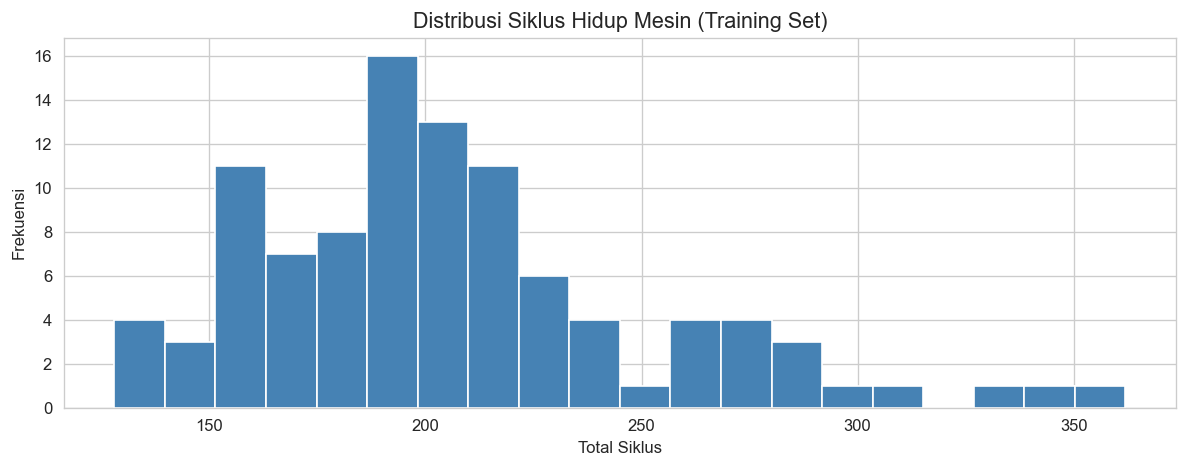

In [6]:
n_units = df_train['unit_number'].nunique()
max_cycles = df_train.groupby('unit_number')['time_in_cycles'].max()

print(f'Jumlah unit (mesin): {n_units}')
print(f'Rata-rata siklus hidup: {max_cycles.mean():.1f}')
print(f'Min siklus: {max_cycles.min()} | Max siklus: {max_cycles.max()}')

plt.figure(figsize=(10, 4))
max_cycles.hist(bins=20, color='steelblue', edgecolor='white')
plt.title('Distribusi Siklus Hidup Mesin (Training Set)', fontsize=13)
plt.xlabel('Total Siklus')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.savefig('../output/eda_lifecycle_distribution.png')
plt.show()

Visualisasi tren sensor untuk beberapa unit

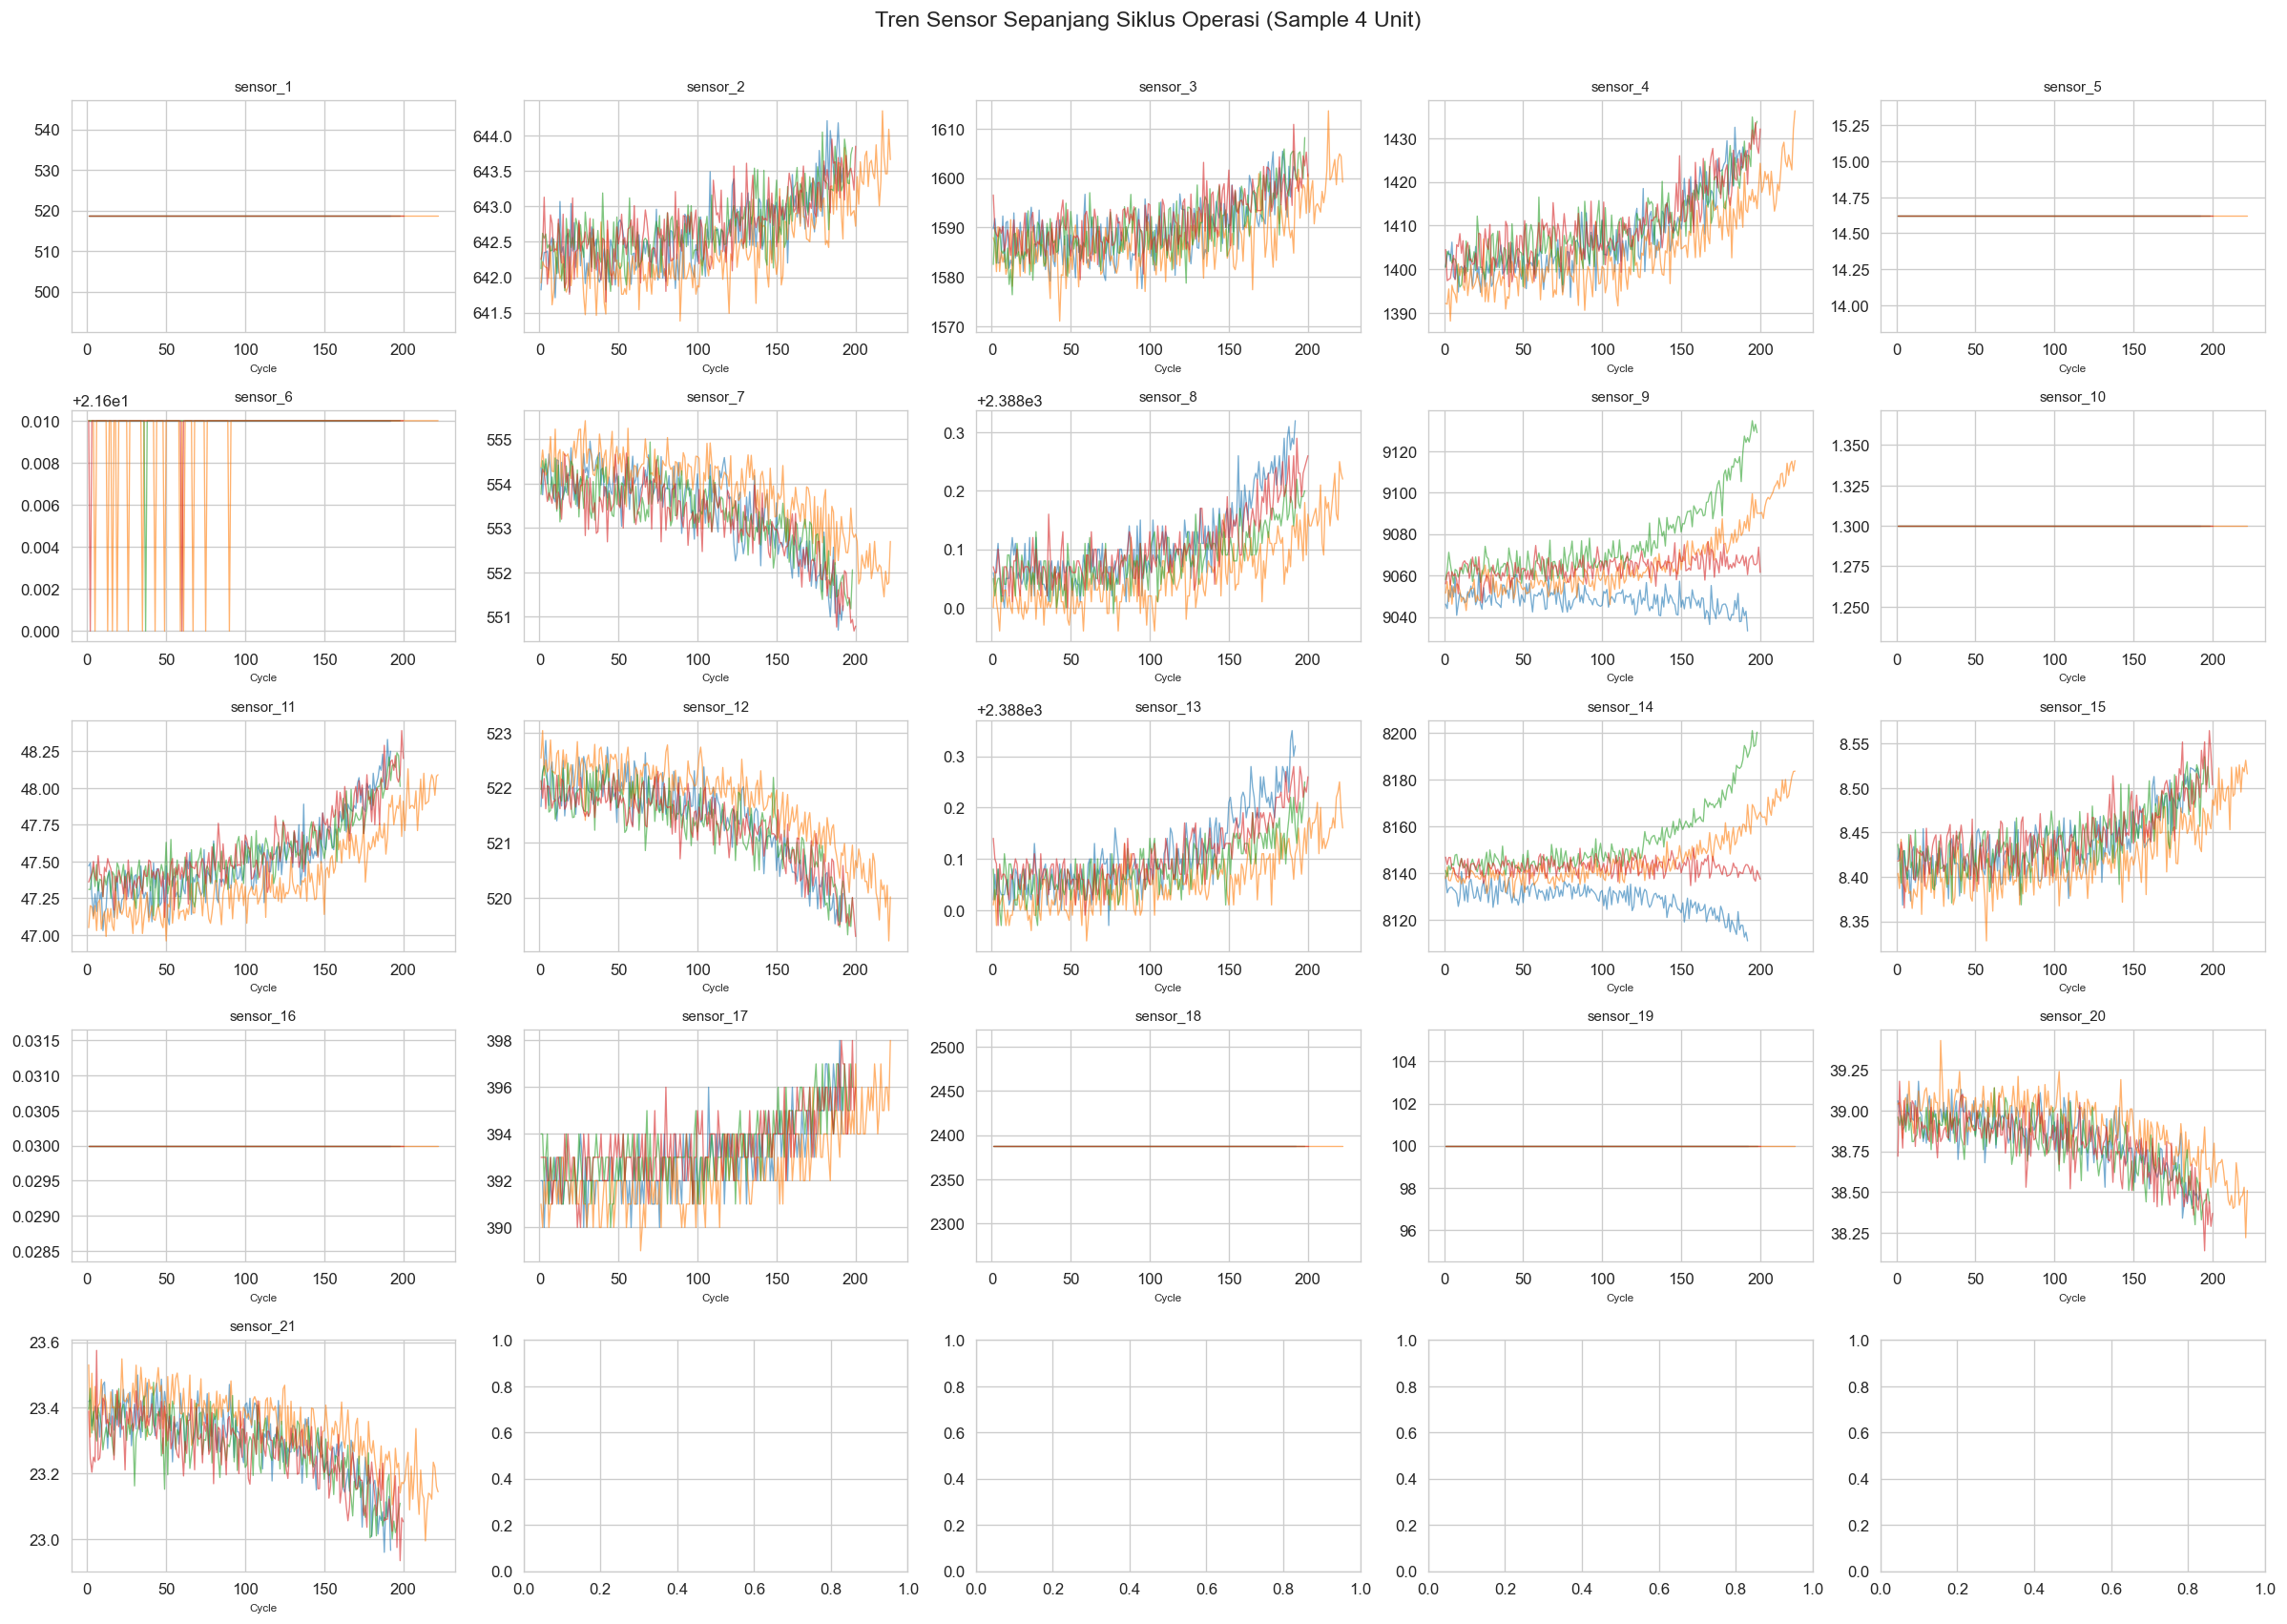

In [7]:
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
sample_units = [1, 10, 50, 100]

fig, axes = plt.subplots(5, 5, figsize=(20, 14))
axes = axes.flatten()

for idx, sensor in enumerate(sensor_cols):
    for unit in sample_units:
        unit_data = df_train[df_train['unit_number'] == unit]
        axes[idx].plot(unit_data['time_in_cycles'], unit_data[sensor], alpha=0.6, linewidth=0.8)
    axes[idx].set_title(sensor, fontsize=9)
    axes[idx].set_xlabel('Cycle', fontsize=7)

plt.suptitle('Tren Sensor Sepanjang Siklus Operasi (Sample 4 Unit)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../output/eda_sensor_trends.png', bbox_inches='tight')
plt.show()

In [ ]:
def plot_multiple_signals(df, sensor_dict, sensors, cols=2):
    rows = int(np.ceil(len(sensors) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    axes = axes.flatten()

    for idx, sensor in enumerate(sensors):
        ax = axes[idx]
        
        for engine_id in df["engine_id"].unique():
            if engine_id % 10 == 0:
                engine_df = df[df["engine_id"] == engine_id]
                ax.plot(
                    engine_df["RUL"],
                    engine_df[sensor].rolling(10).mean(),
                    alpha=0.7
                )

        ax.invert_xaxis()
        ax.set_title(sensor)
        ax.set_xlabel("RUL")
        ax.set_ylabel(sensor_dict[sensor])
        ax.grid(True)

    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_multiple_signals(
    train,
    Sensor_dictionary,
    list(Sensor_dictionary.keys()),
    cols=3
)


Korelasi antar sensor

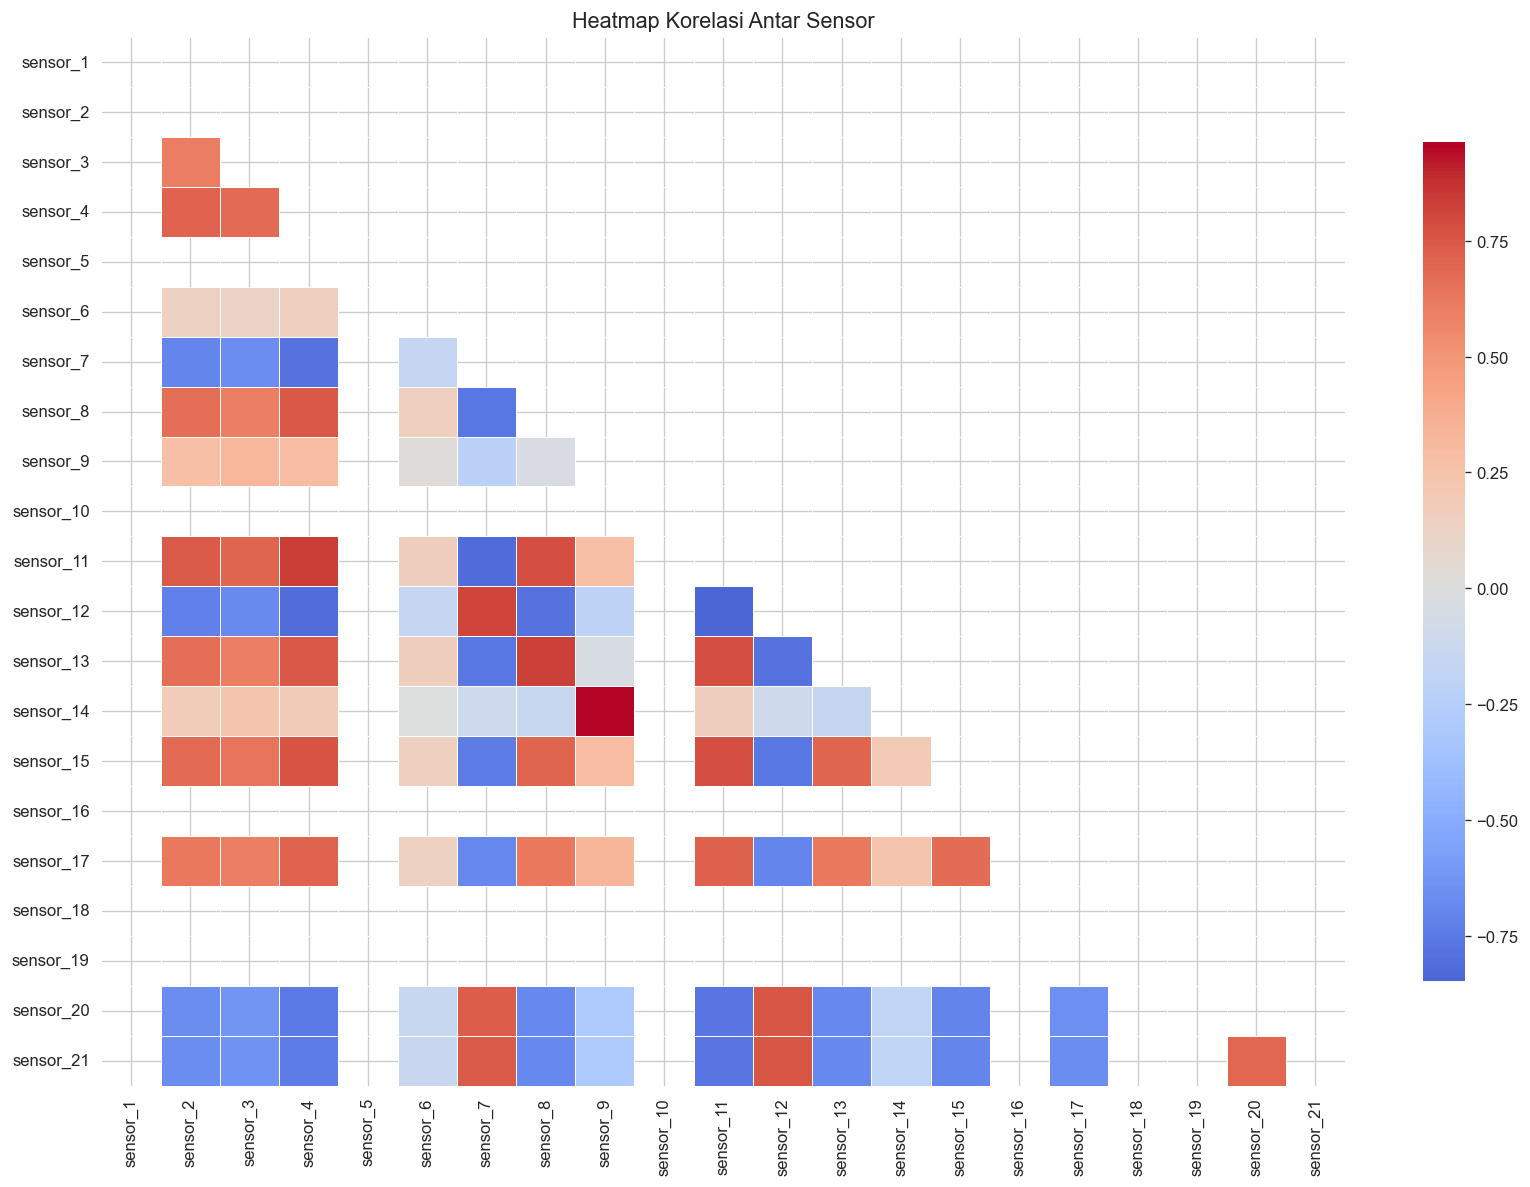

In [8]:
plt.figure(figsize=(14, 10))
corr = df_train[sensor_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Sensor', fontsize=13)
plt.tight_layout()
plt.savefig('../output/eda_sensor_correlation.png')
plt.show()

### Labeling RUL (Remaining Useful Life)

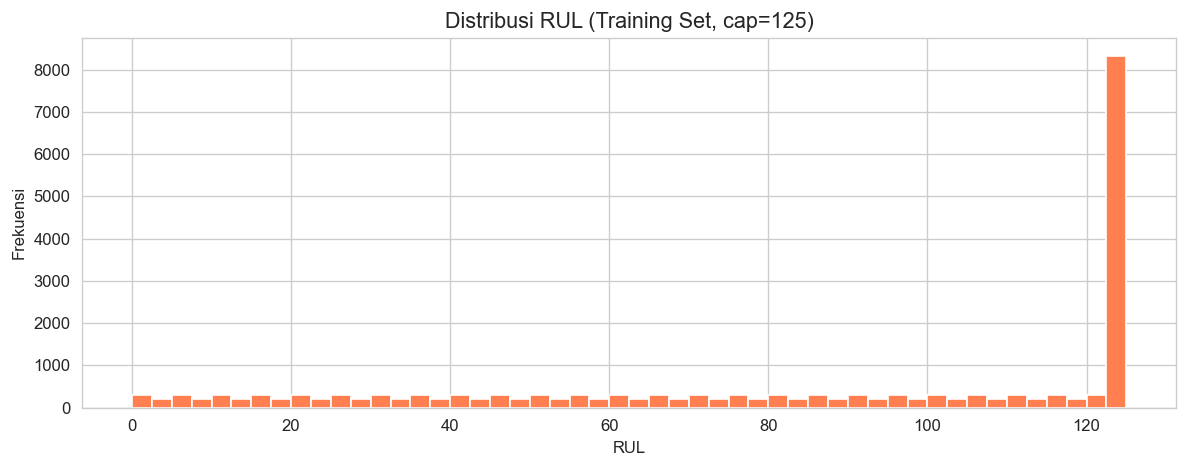

   unit_number  time_in_cycles  RUL
0            1               1  125
1            1               2  125
2            1               3  125
3            1               4  125
4            1               5  125
5            1               6  125
6            1               7  125
7            1               8  125
8            1               9  125
9            1              10  125


In [9]:
MAX_RUL = 125  # Piecewise linear clipping — standar literatur C-MAPSS

def add_rul_label(df, max_rul=MAX_RUL):
    """Tambahkan kolom RUL ke dataframe training."""
    max_cycle = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_cycle.columns = ['unit_number', 'max_cycle']
    df = df.merge(max_cycle, on='unit_number', how='left')
    df['RUL'] = df['max_cycle'] - df['time_in_cycles']
    df['RUL'] = df['RUL'].clip(upper=max_rul)  # Piecewise linear
    df.drop(columns=['max_cycle'], inplace=True)
    return df

df_train = add_rul_label(df_train)

# Distribusi RUL
plt.figure(figsize=(10, 4))
df_train['RUL'].hist(bins=50, color='coral', edgecolor='white')
plt.title(f'Distribusi RUL (Training Set, cap={MAX_RUL})', fontsize=13)
plt.xlabel('RUL')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.savefig('../output/eda_rul_distribution.png')
plt.show()

print(df_train[['unit_number','time_in_cycles','RUL']].head(10))

### Pemilihan Fitur (Feature Selection)

In [10]:
# Drop kolom dengan std = 0 (tidak informatif)
drop_cols = []
check_cols = ['operational_setting_1','operational_setting_2','operational_setting_3'] + sensor_cols

for col in check_cols:
    if df_train[col].std() < 1e-3:
        drop_cols.append(col)

print(f'Kolom di-drop (std ≈ 0): {drop_cols}')

# Kolom fitur final
feature_cols = [c for c in check_cols if c not in drop_cols]
print(f'\nJumlah fitur final: {len(feature_cols)}')
print(f'Fitur: {feature_cols}')

Kolom di-drop (std ≈ 0): ['operational_setting_2', 'operational_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Jumlah fitur final: 16
Fitur: ['operational_setting_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


### Normalisasi Data (Min-Max Scaling)

In [11]:
scaler = MinMaxScaler()

# Fit scaler pada train, transform train & test
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_test[feature_cols]  = scaler.transform(df_test[feature_cols])

print('Normalisasi selesai.')
print(df_train[feature_cols].describe().round(3))

Normalisasi selesai.
       operational_setting_1   sensor_2   sensor_3   sensor_4   sensor_6   sensor_7   sensor_8   sensor_9  sensor_11  sensor_12  sensor_13  sensor_14  sensor_15  sensor_17  sensor_20  sensor_21
count              20631.000  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000
mean                   0.499      0.443      0.425      0.450      0.980      0.566      0.298      0.195      0.411      0.581      0.318      0.226      0.451      0.434      0.524      0.546
std                    0.126      0.151      0.134      0.152      0.139      0.143      0.108      0.099      0.159      0.157      0.106      0.098      0.144      0.129      0.140      0.149
min                    0.000      0.000      0.000      0.000      0.000      0.000      0.000      0.000      0.000      0.000      0.000      0.000      0.000      0.000      0.000      0.000
25%      

### Buat RUL Label untuk Test Set

In [12]:
# Ambil data siklus terakhir tiap mesin di test set
df_test_last = df_test.groupby('unit_number').last().reset_index()
df_test_last['RUL'] = df_rul['RUL'].values
df_test_last['RUL'] = df_test_last['RUL'].clip(upper=MAX_RUL)

print(f'Test last-cycle shape: {df_test_last.shape}')
df_test_last[['unit_number','time_in_cycles','RUL']].head(10)

Test last-cycle shape: (100, 27)


,unit_number,time_in_cycles,RUL
0,1,31,112
1,2,49,98
2,3,126,69
3,4,106,82
4,5,98,91
5,6,105,93
6,7,160,91
7,8,166,95
8,9,55,111
9,10,192,96


### Simpan Data yang Sudah Diproses

In [13]:
df_train.to_csv('../processed/train_processed.csv', index=False)
df_test.to_csv('../processed/test_processed.csv', index=False)
df_test_last.to_csv('../processed/test_last_cycle.csv', index=False)

# Simpan daftar fitur
import json
with open('../processed/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print('Data berhasil disimpan ke folder processed/')
print(f'train_processed.csv    : {df_train.shape}')
print(f'test_processed.csv     : {df_test.shape}')
print(f'test_last_cycle.csv    : {df_test_last.shape}')
print(f'feature_cols.json      : {len(feature_cols)} fitur')

Data berhasil disimpan ke folder processed/
train_processed.csv    : (20631, 27)
test_processed.csv     : (13096, 26)
test_last_cycle.csv    : (100, 27)
feature_cols.json      : 16 fitur
